In [5]:
import os
import json
import pandas as pd
from pathlib import Path

DATA_DIR = Path('./data/accidents/sewik/')

In [6]:
df_counties = pd.read_excel('../../data/input/geographic/Lista-powiatów-Excel.xlsx', sheet_name='Arkusz1')
df_counties.head()

,Województwo,Powiat,Siedziba
0,dolnośląskie,Wrocław,Wrocław
1,dolnośląskie,Jelenia Góra,Jelenia Góra
2,dolnośląskie,Legnica,Legnica
3,dolnośląskie,Wałbrzych,Wałbrzych
4,dolnośląskie,bolesławiecki,Bolesławiec


In [7]:
column_rename = {
    "Województwo": "voivodeship",
    "Powiat": "county",
    "Siedziba": "seat",
}

df_counties.rename(columns=column_rename, inplace=True)
df_counties.head()

,voivodeship,county,seat
0,dolnośląskie,Wrocław,Wrocław
1,dolnośląskie,Jelenia Góra,Jelenia Góra
2,dolnośląskie,Legnica,Legnica
3,dolnośląskie,Wałbrzych,Wałbrzych
4,dolnośląskie,bolesławiecki,Bolesławiec


In [8]:
import geopandas as gpd
import pandas as pd

# Read both shapefiles
county_geodata = gpd.read_file('../../scratchpad/data/locations/powiaty/powiaty.shp')
voivodeship_geodata = gpd.read_file('../../scratchpad/data/locations/wojewodztwa/wojewodztwa.shp')

# Transform both to the same projected CRS
county_geodata_projected = county_geodata.to_crs(epsg=2180)
voivodeship_geodata_projected = voivodeship_geodata.to_crs(epsg=2180)

# Calculate centroids in the projected system
centroids = county_geodata_projected.copy()
centroids['geometry'] = county_geodata_projected['geometry'].centroid

# Spatial join to find which voivodeship contains each centroid
df_centroids = gpd.sjoin(
    centroids, 
    voivodeship_geodata_projected, 
    how="left", 
    predicate="within"
)

# Transform back to WGS84
df_centroids = df_centroids.to_crs(epsg=4326)

# Extract coordinates and clean names
df_centroids['longitude'] = df_centroids.geometry.x
df_centroids['latitude'] = df_centroids.geometry.y
df_centroids['county'] = df_centroids['JPT_NAZWA__left'].str.replace('powiat ', '')
df_centroids['voivodeship'] = df_centroids['JPT_NAZWA__right'].str.replace('województwo ', '')

# Create the final dataframe
df_coords = pd.DataFrame({
    'county': df_centroids['county'],
    'voivodeship': df_centroids['voivodeship'],
    'latitude': df_centroids['latitude'],
    'longitude': df_centroids['longitude']
})

# Merge with df_counties
df_counties = df_counties.merge(df_coords, on=['county', 'voivodeship'], how='left')

# Print any missing values to check if the merge worked correctly
print("Missing values after merge:\n", df_counties.isnull().sum())
df_counties

Missing values after merge:
 voivodeship    0
county         0
seat           0
latitude       1
longitude      1
dtype: int64


,voivodeship,county,seat,latitude,longitude
0,dolnośląskie,Wrocław,Wrocław,51.127696,16.996109
1,dolnośląskie,Jelenia Góra,Jelenia Góra,50.870921,15.708025
2,dolnośląskie,Legnica,Legnica,51.201708,16.167485
3,dolnośląskie,Wałbrzych,Wałbrzych,50.786418,16.290013
4,dolnośląskie,bolesławiecki,Bolesławiec,51.336902,15.536946
...,...,...,...,...,...
375,zachodniopomorskie,sławieński,Sławno,54.374417,16.592769
376,zachodniopomorskie,stargardzki,Stargard Szczeciński,53.351914,15.218284
377,zachodniopomorskie,szczecinecki,Szczecinek,53.734886,16.581079
378,zachodniopomorskie,świdwiński,Świdwin,53.797865,15.879860


In [9]:
# Monkeypatch this
df_counties.loc[df_counties['county'] == 'jeleniogórski', 'latitude'] = df_counties.loc[df_counties['county'] == 'Jelenia Góra', 'latitude'].values[0]
df_counties.loc[df_counties['county'] == 'jeleniogórski', 'longitude'] = df_counties.loc[df_counties['county'] == 'Jelenia Góra', 'longitude'].values[0]

df_counties

,voivodeship,county,seat,latitude,longitude
0,dolnośląskie,Wrocław,Wrocław,51.127696,16.996109
1,dolnośląskie,Jelenia Góra,Jelenia Góra,50.870921,15.708025
2,dolnośląskie,Legnica,Legnica,51.201708,16.167485
3,dolnośląskie,Wałbrzych,Wałbrzych,50.786418,16.290013
4,dolnośląskie,bolesławiecki,Bolesławiec,51.336902,15.536946
...,...,...,...,...,...
375,zachodniopomorskie,sławieński,Sławno,54.374417,16.592769
376,zachodniopomorskie,stargardzki,Stargard Szczeciński,53.351914,15.218284
377,zachodniopomorskie,szczecinecki,Szczecinek,53.734886,16.581079
378,zachodniopomorskie,świdwiński,Świdwin,53.797865,15.879860


In [10]:
df_counties.latitude.isna().sum(), df_counties.longitude.isna().sum()

(np.int64(0), np.int64(0))

## Add elevation

In [11]:
# https://ec.europa.eu/eurostat/web/gisco/geodata/digital-elevation-model/copernicus#Elevation

import rasterio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.warp import transform_bounds, transform
from rasterio.mask import mask
from shapely.geometry import box

# Load DEM data functions
def load_dem_data(dem_filepath):
    """
    Load Digital Elevation Model data and create an interpolation function
    """
    with rasterio.open(dem_filepath) as dem:
        elevation = dem.read(1)
        transform = dem.transform
        bounds = dem.bounds
        
        return elevation, transform, bounds

def get_elevation_for_point(lat, lon, elevation, transform):
    """
    Get elevation for a specific lat/lon point
    """
    row, col = ~transform * (lon, lat)
    row, col = int(row), int(col)
    
    if (0 <= row < elevation.shape[0] and 
        0 <= col < elevation.shape[1]):
        return elevation[col, row]
    return np.nan

# Load the DEM data
dem_filepath = '../../data/input/geographic/poland_dem.tif'
elevation_data, dem_transform, dem_bounds = load_dem_data(dem_filepath)

In [12]:
df_counties['elevation'] = df_counties.apply(lambda row: get_elevation_for_point(row['latitude'], row['longitude'], elevation_data, dem_transform), axis=1)
df_counties

,voivodeship,county,seat,latitude,longitude,elevation
0,dolnośląskie,Wrocław,Wrocław,51.127696,16.996109,120.739639
1,dolnośląskie,Jelenia Góra,Jelenia Góra,50.870921,15.708025,364.133362
2,dolnośląskie,Legnica,Legnica,51.201708,16.167485,119.268547
3,dolnośląskie,Wałbrzych,Wałbrzych,50.786418,16.290013,426.732391
4,dolnośląskie,bolesławiecki,Bolesławiec,51.336902,15.536946,179.133652
...,...,...,...,...,...,...
375,zachodniopomorskie,sławieński,Sławno,54.374417,16.592769,26.047045
376,zachodniopomorskie,stargardzki,Stargard Szczeciński,53.351914,15.218284,55.281879
377,zachodniopomorskie,szczecinecki,Szczecinek,53.734886,16.581079,155.027344
378,zachodniopomorskie,świdwiński,Świdwin,53.797865,15.879860,116.519508


In [13]:
df_counties.elevation.isna().sum()

np.int64(0)

In [14]:
df_counties.to_csv('../../data/intermediate/counties.csv', index=False)

## Calculate daily weather

old method - with results from the nearest station

In [15]:
df_weather_stations = pd.read_csv('../../data/intermediate/weather_stations.csv')
df_weather_stations.head()

,id,name,latitude,longitude,elevation,temperature_start_date,precipitation_start_date,humidity_start_date,category
0,249170080,Dzierżkowice,49.992222,17.846389,270.0,NaN,NaN,NaN,No data
1,249180010,Pszczyna,49.995556,18.919167,270.0,2015-01,2019-04,2015-01,"Precipitation, Temperature, Humidity"
2,249180020,Warszowice,49.991944,18.705556,270.0,NaN,2015-01,NaN,Precipitation only
3,249180030,Chałupki,49.925833,18.327500,198.0,NaN,NaN,NaN,No data
4,249180070,Mazańcowice,49.862500,18.969444,269.0,NaN,2015-01,NaN,Precipitation only


In [ ]:
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
from pykrige.uk import UniversalKriging
import pyproj
from datetime import datetime
import matplotlib.pyplot as plt

# Map weather parameter codes to desired names
param_map = {'B00300S': 'temperature', 'B00604S': 'precipation', 'B00802A': 'humidity'}

def transform_coordinates(lons, lats, zone=34):
    """Transform coordinates from WGS84 to UTM projection"""
    utm_proj = pyproj.Proj(proj='utm', zone=zone, ellps='WGS84')
    x, y = utm_proj(lons, lats)
    return x, y

def find_candidate_stations(lat, lon, kdtree, station_ids, max_distance_km=150, k=10):
    """Find candidate stations ordered by proximity"""
    query_coords = np.radians(np.array([[lat, lon]]))
    distances, indices = kdtree.query(query_coords, k=k)
    distances_km = distances.flatten() * 6371  # Convert radian distances to km
    candidates = [str(s) for s in station_ids[indices.flatten()][distances_km < max_distance_km]]
    return candidates

def create_station_kdtree(df_stations):
    """Create KDTree for fast spatial lookups"""
    coords = np.radians(df_stations[['latitude', 'longitude']].values)
    return cKDTree(coords), df_stations['id'].values

def get_measurements_df(param: str, year: int, month: int) -> pd.DataFrame:
    """Load weather measurements from CSV files"""
    from pathlib import Path
    measurement_path = Path('../../data/input/weather/') / str(year) / str(month).zfill(2) / f'{param}_{year}_{str(month).zfill(2)}.csv'
    columns = ['Station ID', 'Measurement', 'Datetime', 'Value']
    df_measurements = pd.read_csv(measurement_path, sep=';', encoding='windows-1250', names=columns, header=None, index_col=False, dtype={'Station ID': str, 'Value': str, 'Datetime': str, 'Measurement': str})

    # df_measurements['Station ID'] = pd.to_numeric(df_measurements['Station ID'], errors='coerce').astype('Int64')
    df_measurements['Station ID'] = df_measurements['Station ID'].astype('str')
    df_measurements['Value'] = df_measurements['Value'].str.replace(',', '.').astype(float)
    df_measurements['Datetime'] = pd.to_datetime(df_measurements['Datetime'])

    return df_measurements

def interpolate_parameter_for_date(counties_df, weather_stations_df, weather_data_df, param, date):
    """
    Interpolate weather parameter values for county centroids using Universal Kriging with elevation drift
    """
    interpolated_values = []
    
    # Filter stations with data for this parameter and date
    stations_with_data = weather_data_df[(weather_data_df['date'] == date) & 
                                        (weather_data_df['parameter'] == param)]
    
    # If no stations have data for this date/parameter, return NaN for all counties
    if stations_with_data.empty:
        return [np.nan] * len(counties_df)
    
    # Add this after loading weather_stations_df
    weather_stations_df['id'] = weather_stations_df['id'].astype(str)
    # Merge with station metadata to get coordinates and elevation
    stations = stations_with_data.merge(weather_stations_df, 
                                       left_on='Station ID', 
                                       right_on='id', 
                                       how='inner')
    
    # If fewer than 5 stations with data, fall back to nearest station method
    if len(stations) < 5:
        # Create a lookup dict for station values
        station_values = dict(zip(stations['id'].astype(str), stations['Value']))
        
        # For each county, find the nearest station with data
        for _, county in counties_df.iterrows():
            nearest_found = False
            for station_id in county['station_candidates']:
                if station_id in station_values:
                    interpolated_values.append(station_values[station_id])
                    nearest_found = True
                    break
            if not nearest_found:
                interpolated_values.append(np.nan)
        return interpolated_values
    
    # Transform coordinates to UTM
    lons = stations['longitude'].values
    lats = stations['latitude'].values
    x, y = transform_coordinates(lons, lats)
    vals = stations['Value'].values
    elevations = stations['elevation'].values
    
    try:
        # Check if all values are the same
        if np.all(vals == vals[0]):
            return [vals[0]] * len(counties_df)
        
        # Create Universal Kriging model with elevation as a drift term
        variogram_model = 'spherical' if param == 'precipation' else 'linear'
        UK = UniversalKriging(
            x, y, vals,
            variogram_model=variogram_model,
            drift_terms=['specified'],
            specified_drift=[elevations.reshape(-1, 1)],
        )
        
        # For each county, predict the parameter value
        for _, county in counties_df.iterrows():
            county_x, county_y = transform_coordinates([county['longitude']], [county['latitude']])
            county_elev = county['elevation']
            
            # Execute kriging for the county location
            value, _ = UK.execute(
                style='points',
                xpoints=np.array([county_x[0]]),
                ypoints=np.array([county_y[0]]),
                specified_drift_arrays=[np.array([county_elev])],
            )
            
            # Apply basic constraints based on parameter
            if param == 'precipation':
                value = max(0, value[0])
            elif param == 'humidity':
                value = max(0, min(100, value[0]))
            else:
                value = value[0]
                
            interpolated_values.append(value)
            
    except Exception as e:
        print(f"Error interpolating {param} for date {date}: {e}")
        # Fall back to nearest station method
        station_values = dict(zip(stations['id'].astype(str), stations['Value']))
        
        for _, county in counties_df.iterrows():
            nearest_found = False
            for station_id in county['station_candidates']:
                if station_id in station_values:
                    interpolated_values.append(station_values[station_id])
                    nearest_found = True
                    break
            if not nearest_found:
                interpolated_values.append(np.nan)
    
    return interpolated_values

# Create KDTree for weather stations
kdtree, station_ids = create_station_kdtree(df_weather_stations)

# For each county, get candidate station list ordered by proximity
df_counties['station_candidates'] = df_counties.apply(
    lambda row: find_candidate_stations(row['latitude'], row['longitude'], kdtree, station_ids),
    axis=1
)

# Aggregate measurements per parameter over available months
all_param_dfs = []
for param, param_name in param_map.items():
    param_dfs = []
    # Adjust these ranges to cover the complete period
    for year in range(2015, 2019):
        for month in range(1, 13):
            try:
                df_meas = get_measurements_df(param, year, month)
            except Exception:
                continue  # Skip missing files
            
            # Ensure station IDs are strings
            df_meas['Station ID'] = df_meas['Station ID'].astype(str)
            # Create date column from measurement datetime
            df_meas['date'] = df_meas['Datetime'].dt.date
            
            # Group by station and date to get daily averages
            df_grouped = df_meas.groupby(['Station ID', 'date'], as_index=False)['Value'].mean()
            param_dfs.append(df_grouped)
    
    if not param_dfs:
        continue
    
    df_param = pd.concat(param_dfs, ignore_index=True)
    df_param['parameter'] = param_name
    all_param_dfs.append(df_param)

if all_param_dfs:
    # Combine all weather measurements into one long DataFrame
    df_weather_long = pd.concat(all_param_dfs, ignore_index=True)
    
    # Define date range
    all_dates = pd.date_range('2015-01-01', '2019-12-31').date
    
    # Process in batches to avoid memory issues
    batch_size = 30  # Process 30 days at a time
    records = []
    
    for i in range(0, len(all_dates), batch_size):
        batch_dates = all_dates[i:i+batch_size]
        print(f"Processing dates: {batch_dates[0]} to {batch_dates[-1]}")
        
        for day in batch_dates:
            print(f"  Interpolating weather for {day}")
            
            # For each parameter, interpolate values for all counties on this day
            county_data = []
            for param_name in param_map.values():
                # Get interpolated values for this parameter
                param_values = interpolate_parameter_for_date(
                    df_counties, 
                    df_weather_stations, 
                    df_weather_long[df_weather_long['parameter'] == param_name],
                    param_name,
                    day
                )
                
                # Store as (county_index, parameter_value) pairs
                county_data.append((param_name, param_values))
            
            # Create records for each county
            for county_idx, county_row in df_counties.iterrows():
                daily_record = {
                    'date': day,
                    'county': county_row['county'],
                    'voivodeship': county_row['voivodeship'],
                    'seat': county_row['seat']
                }
                
                # Add interpolated parameter values
                for param_name, values in county_data:
                    daily_record[param_name] = values[county_idx]
                
                records.append(daily_record)
    
    # Create final DataFrame with one row per county per day
    df_weather_daily = pd.DataFrame(records)
    
    # Sort values by date and county
    df_weather_daily.sort_values(by=['date', 'county'], inplace=True)
    
    # Display a sample of the results
    print(df_weather_daily.head())
    
    # Save the results to CSV
    df_weather_daily.to_csv('../../data/intermediate/weather_daily_kriging2.csv', index=False)
else:
    print("No weather measurement files available for the given parameters and period.")

In [44]:
df_weather_daily.isna().sum()

date           0
county         0
voivodeship    0
seat           0
temperature    0
precipation    0
humidity       0
dtype: int64

In [45]:
df_weather_daily

,date,county,voivodeship,seat,temperature,precipation,humidity
54,2015-01-01,Biała Podlaska,lubelskie,Biała Podlaska,0.466584,0.317923,93.475093
216,2015-01-01,Białystok,podlaskie,Białystok,0.755842,1.953422,94.665032
254,2015-01-01,Bielsko-Biała,śląskie,Bielsko-Biała,0.178197,0.572180,88.248470
30,2015-01-01,Bydgoszcz,kujawsko-pomorskie,Bydgoszcz,2.129915,0.090402,91.987748
255,2015-01-01,Bytom,śląskie,Bytom,-1.447255,0.000000,90.387342
...,...,...,...,...,...,...,...
554890,2018-12-31,żarski,lubuskie,Żary,3.078380,3.496512,90.482753
554852,2018-12-31,żniński,kujawsko-pomorskie,Żnin,2.436609,3.025265,89.007494
554977,2018-12-31,żuromiński,mazowieckie,Żuromin,2.397563,3.254790,88.654360
554978,2018-12-31,żyrardowski,mazowieckie,Żyrardów,2.640164,3.436984,88.037757


In [1]:
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree

def create_station_kdtree(df_stations):
    """Create KDTree for fast spatial lookups"""
    coords = np.radians(df_stations[['latitude', 'longitude']].values)
    return cKDTree(coords), df_stations['id'].values

def find_nearest_stations(lat, lon, kdtree, station_ids, max_distance_km=50):
    """Find nearest stations using KDTree"""
    query_coords = np.radians(np.array([[lat, lon]]))
    distances, indices = kdtree.query(query_coords, k=10)  # Get 5 nearest stations
    # Convert distances from radians to km (Earth radius ≈ 6371 km)
    distances_km = distances.flatten() * 6371
    mask = distances_km < max_distance_km
    return station_ids[indices.flatten()[mask]]

In [2]:

def get_measurements_df(param: str, year: int, month: int) -> pd.DataFrame:
    measurement_path = Path('../../data/input/weather/') / str(year) / str(month).zfill(2) / f'{param}_{year}_{str(month).zfill(2)}.csv'
    columns = ['Station ID', 'Measurement', 'Datetime', 'Value']
    df_measurements = pd.read_csv(measurement_path, sep=';', encoding='windows-1250', names=columns, header=None, index_col=False, dtype={'Station ID': str, 'Value': str, 'Datetime': str, 'Measurement': str})

    df_measurements['Value'] = df_measurements['Value'].str.replace(',', '.').astype(float)
    df_measurements['Datetime'] = pd.to_datetime(df_measurements['Datetime'])

    return df_measurements

In [ ]:
import numpy as np
import pandas as pd

# Map weather parameter codes to desired names
param_map = {'B00300S': 'temperature', 'B00604S': 'precipation', 'B00802A': 'humidity'}

# Replace the single nearest station function with one that returns candidate stations.
def find_candidate_stations(lat, lon, kdtree, station_ids, max_distance_km=150, k=10):
    query_coords = np.radians(np.array([[lat, lon]]))
    distances, indices = kdtree.query(query_coords, k=k)
    distances_km = distances.flatten() * 6371  # Convert radian distances to km
    # Convert candidate station IDs to str for consistency.
    candidates = [str(s) for s in station_ids[indices.flatten()][distances_km < max_distance_km]]
    return candidates

# Create KDTree for weather stations (assumes df_weather_stations is available)
kdtree, station_ids = create_station_kdtree(df_weather_stations)

# For each county (county seat), get a candidate station list (ordered by proximity)
df_counties['station_candidates'] = df_counties.apply(
    lambda row: find_candidate_stations(row['latitude'], row['longitude'], kdtree, station_ids),
    axis=1
)

# Aggregate measurements per parameter over available months.
all_param_dfs = []
for param, param_name in param_map.items():
    param_dfs = []
    # Adjust these ranges to cover the complete period.
    # for year in range(2015, 2024):
    for year in range(2020, 2024):
        for month in range(1, 13):
            try:
                df_meas = get_measurements_df(param, year, month)
            except Exception:
                continue  # Skip missing files
            # Ensure the station IDs are strings.
            df_meas['Station ID'] = df_meas['Station ID'].astype(str)
            # Create a date column from the measurement datetime.
            df_meas['date'] = df_meas['Datetime'].dt.date

            df_grouped = df_meas.groupby(['Station ID', 'date'], as_index=False)['Value'].mean()
            param_dfs.append(df_grouped)
    if not param_dfs:
        continue
    df_param = pd.concat(param_dfs, ignore_index=True)
    df_param['parameter'] = param_name
    all_param_dfs.append(df_param)

if all_param_dfs:
    # Combine all weather measurements into one long DataFrame.
    df_weather_long = pd.concat(all_param_dfs, ignore_index=True)
    
    # Build a lookup dictionary for measurements.
    # Key: (station_id, date, parameter)  Value: measurement value.
    measurement_map = {}
    for _, row in df_weather_long.iterrows():
        st_id = str(row['Station ID'])  # ensure identifier is a string
        key = (st_id, row['date'], row['parameter'])
        measurement_map[key] = row['Value']
    
    # Define the overall date range (each day) from Jan 1, 2015 to Dec 31, 2023.
    # all_dates = pd.date_range('2015-01-01', '2023-12-31').date
    all_dates = pd.date_range('2020-01-01', '2023-12-31').date
    
    records = []
    # For each county, for each day, try candidate stations for every weather parameter.
    for _, county_row in df_counties.iterrows():
        county = county_row['county']
        voivodeship = county_row['voivodeship']
        seat = county_row['seat']
        candidates = county_row['station_candidates']
        # Process each date
        for day in all_dates:
            daily_record = {
                'date': day,
                'county': county,
                'voivodeship': voivodeship,
                'seat': seat
            }
            # For each weather parameter, check candidate stations in order.
            for weather_param in param_map.values():
                found = False
                for st in candidates:
                    key = (str(st), day, weather_param)
                    if key in measurement_map:
                        daily_record[weather_param] = measurement_map[key]
                        found = True
                        break
                if not found:
                    daily_record[weather_param] = np.nan
            records.append(daily_record)
    
    # Create final DataFrame with one row per county per day.
    df_weather_daily = pd.DataFrame(records)
    # Optional: sort values by date and county.
    df_weather_daily.sort_values(by=['date', 'county'], inplace=True)
    
    # Display a sample of the results
    print(df_weather_daily.head())
else:
    print("No weather measurement files available for the given parameters and period.")

              date          county         voivodeship            seat  \
78894   2020-01-01  Biała Podlaska           lubelskie  Biała Podlaska   
315576  2020-01-01       Białystok           podlaskie       Białystok   
371094  2020-01-01   Bielsko-Biała             śląskie   Bielsko-Biała   
43830   2020-01-01       Bydgoszcz  kujawsko-pomorskie       Bydgoszcz   
372555  2020-01-01           Bytom             śląskie           Bytom   

        temperature  precipation   humidity  
78894      1.562222          0.2  83.101042  
315576     1.303472          2.6  86.097222  
371094     0.604167          0.0  79.145833  
43830      1.730556          0.3  85.683333  
372555     1.634225          0.0  84.306831  


In [20]:
df_weather_daily

,date,county,voivodeship,seat,temperature,precipation,humidity
78894,2020-01-01,Biała Podlaska,lubelskie,Biała Podlaska,1.562222,0.2,83.101042
315576,2020-01-01,Białystok,podlaskie,Białystok,1.303472,2.6,86.097222
371094,2020-01-01,Bielsko-Biała,śląskie,Bielsko-Biała,0.604167,0.0,79.145833
43830,2020-01-01,Bydgoszcz,kujawsko-pomorskie,Bydgoszcz,1.730556,0.3,85.683333
372555,2020-01-01,Bytom,śląskie,Bytom,1.634225,0.0,84.306831
...,...,...,...,...,...,...,...
132950,2023-12-31,żarski,lubuskie,Żary,NaN,1.0,NaN
77432,2023-12-31,żniński,kujawsko-pomorskie,Żnin,3.205556,1.1,91.811806
260057,2023-12-31,żuromiński,mazowieckie,Żuromin,1.969861,0.6,99.494722
261518,2023-12-31,żyrardowski,mazowieckie,Żyrardów,3.078472,0.7,88.958333


In [21]:
df_weather_daily.describe()

,temperature,precipation,humidity
count,538213.000000,555180.000000,541105.000000
mean,9.572379,1.709218,77.274973
std,7.814181,4.782675,13.445510
min,-23.160417,0.000000,0.000000
25%,3.269444,0.000000,68.482986
50%,9.371250,0.000000,78.965278
75%,16.091667,1.300000,87.741319
max,47.697619,1196.800000,104.000000


In [22]:
df_weather_daily.nlargest(100, 'precipation')

,date,county,voivodeship,seat,temperature,precipation,humidity
467927,2021-02-11,ostródzki,warmińsko-mazurskie,Ostróda,-14.437483,1196.8,81.587847
1776,2020-11-11,Jelenia Góra,dolnośląskie,Jelenia Góra,2.106569,214.4,91.649635
13464,2020-11-11,jeleniogórski,dolnośląskie,Jelenia Góra,2.106569,214.4,91.649635
1865,2021-02-08,Jelenia Góra,dolnośląskie,Jelenia Góra,-9.540972,210.7,79.479167
13553,2021-02-08,jeleniogórski,dolnośląskie,Jelenia Góra,-9.540972,210.7,79.479167
...,...,...,...,...,...,...,...
418024,2020-06-27,wodzisławski,śląskie,Wodzisław Śląski,21.702083,66.8,77.430556
208070,2021-08-31,białobrzeski,mazowieckie,Białobrzegi,15.230556,66.8,91.617014
112662,2020-06-14,Gorzów Wielkopolski,lubuskie,Gorzów Wielkopolski,20.379167,66.7,59.756944
115584,2020-06-14,gorzowski,lubuskie,Gorzów Wielkopolski,20.379167,66.7,59.756944


<Axes: ylabel='Frequency'>

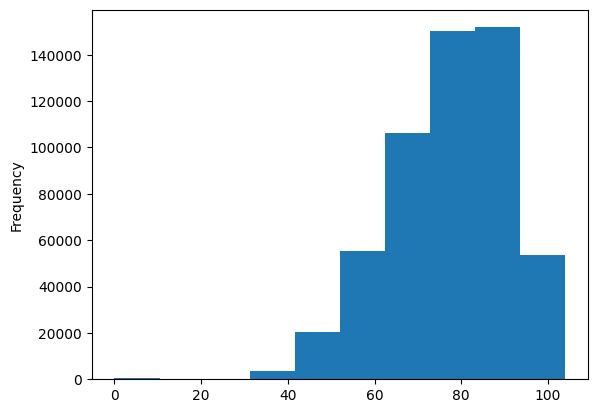

In [23]:
df_weather_daily.humidity.plot.hist()

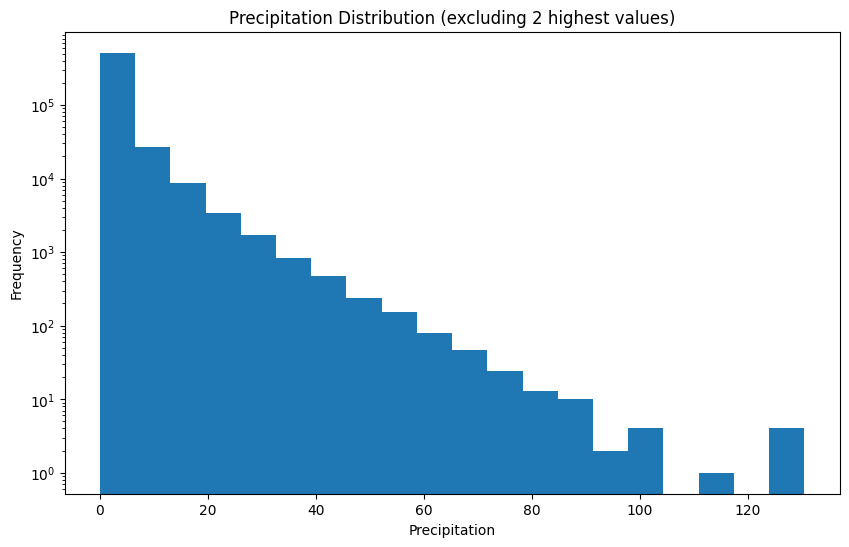

In [29]:
import matplotlib.pyplot as plt

# Sort values and exclude 2 highest values
data = df_weather_daily['precipation'].dropna().sort_values()[:-5]

plt.figure(figsize=(10, 6))
plt.hist(data, bins=20)
plt.title('Precipitation Distribution (excluding 2 highest values)')
plt.xlabel('Precipitation')
plt.ylabel('Frequency')
plt.yscale('log')
plt.show()

In [ ]:
df_weather_daily.to_csv('../../data/intermediate/weather_daily2.csv', index=False)